In [100]:
# imports & global settings
import os
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

# Plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

#

# sklearn basics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC

# Optional (try to import XGBoost/LightGBM if installed)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

RANDOM_STATE = 42


In [101]:
# load dataset
path = r"C:/Users/AB-TECH/Desktop/ML Projects/Internship Projects/Task 4/iris.csv"
assert os.path.exists(path), f"File not found: {path}"

df = pd.read_csv(path)
print("Loaded iris dataset -> shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))
print("\nColumn dtypes:\n", df.dtypes)


Loaded iris dataset -> shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Column dtypes:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [102]:
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    fig = px.histogram(
        df,
        x=col,
        color="species",
        marginal="box",   # adds boxplot above
        nbins=20,
        title=f"Distribution of {col} by Species"
    )
    fig.show()


In [103]:
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    fig = px.violin(
        df,
        x="species",
        y=col,
        color="species",
        box=True,
        points="all",
        title=f"Violin Plot of {col} by Species"
    )
    fig.show()


In [104]:
fig = px.scatter_matrix(
    df,
    dimensions=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    color='species',
    title="Scatter Matrix - Pairwise Feature Relationships",
    symbol='species',
    opacity=0.7
)
fig.update_traces(diagonal_visible=False)
fig.show()


In [105]:
# Correlation Heatmap
corr = df.drop(columns=['species']).corr()
fig3 = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="Viridis",
    title="Feature Correlation Heatmap"
)
fig3.show()

# Class Count (species ka distribution)
fig4 = px.histogram(
    df,
    x="species",
    color="species",
    title="Count of Each Iris Species",
    text_auto=True
)
fig4.show()

Text(0.5, 1.0, 'Species vs Sepal Length')

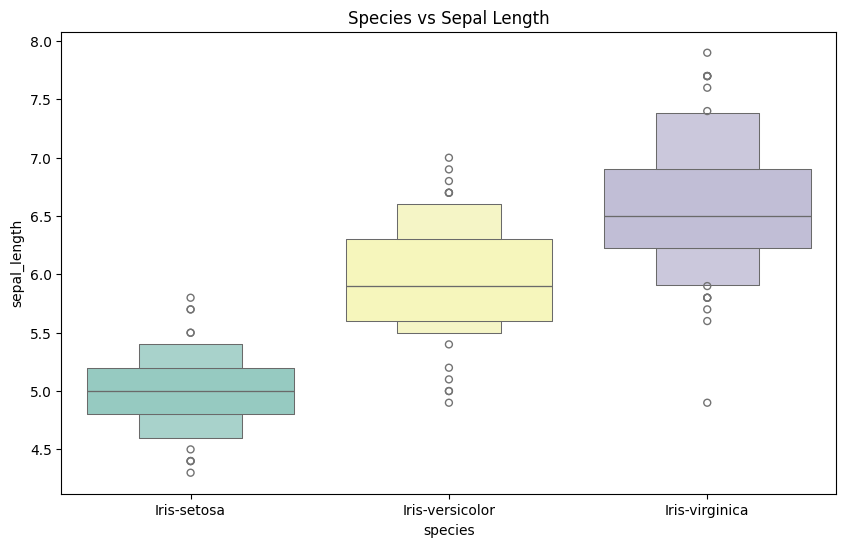

In [106]:
fig = plt.figure(figsize=(10, 6))
sns.boxenplot(data=df, x='species', y='sepal_length', palette='Set3')
plt.title('Species vs Sepal Length')

In [107]:
# Auto-detect target column
# Preferred names (common patterns); falls back to last object/categorical column, or last column.
possible_names = ['species', 'target', 'class', 'label', 'species_name', 'variety']
target_col = None
for name in possible_names:
    if name in df.columns:
        target_col = name
        break

if target_col is None:
    # pick an object/categorical column if exists
    obj_cols = df.select_dtypes(include=['object','category']).columns.tolist()
    if obj_cols:
        target_col = obj_cols[-1]  # choose the last textual column
    else:
        # fallback: choose last column (use with caution)
        target_col = df.columns[-1]

print("Detected target column:", target_col)


Detected target column: species


In [108]:
# %% Step 3 - quick EDA
feature_cols = [c for c in df.columns if c != target_col]

# Show unique target values
print("Unique labels (raw):", df[target_col].unique())
print("Value counts:\n", df[target_col].value_counts())

# Scatter matrix (pairwise) — interactive
try:
    fig = px.scatter_matrix(df, dimensions=feature_cols, color=target_col,
                            title="Pairwise scatter (interactive)")
    fig.update_layout(height=800)
    fig.show()
except Exception as e:
    print("scatter_matrix error:", e)

# Correlation heatmap (numeric features only)
num = df[feature_cols].select_dtypes(include=[np.number])
if not num.empty:
    corr = num.corr()
    fig = px.imshow(corr, text_auto=True, zmin=-1, zmax=1, color_continuous_scale='RdBu',
                    title="Correlation heatmap")
    fig.show()


Unique labels (raw): ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Value counts:
 species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [109]:
# %% Step 4 - label encoding + feature selection
# Convert target to numeric if needed (many classifiers expect numeric labels)
le = LabelEncoder()
y_raw = df[target_col]
y = le.fit_transform(y_raw)  # transforms strings like 'Iris-setosa' -> 0,1,2
print("Label classes:", le.classes_)

# Prepare X: if there are categorical features, they will be handled in preprocessor
X = df[feature_cols].copy()
print("Feature columns used:", list(X.columns))


Label classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Feature columns used: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [110]:
# %% Step 5 - preprocessing
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Numeric transformer: median impute -> scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer: most frequent impute -> one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # <- change here
])

transformers = []
transformers.append(('num', numeric_transformer, numeric_features))
if categorical_features:
    transformers.append(('cat', categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Categorical features: []


In [111]:
# %% Step 6 - split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train/Test shapes:", X_train.shape, X_test.shape)


Train/Test shapes: (120, 4) (30, 4)


In [112]:
# %% Step 7 - define classifiers factory
def get_classifiers(random_state=RANDOM_STATE):
    models = {
        "LogisticRegression": LogisticRegression(max_iter=500, multi_class='auto', random_state=random_state),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=random_state),
        "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=random_state),
        "SVC_linear": SVC(kernel='linear', probability=True, random_state=random_state)
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=random_state)
    if HAS_LGB:
        models["LightGBM"] = lgb.LGBMClassifier(n_estimators=200, random_state=random_state)
    return models

models = get_classifiers()
print("Available models:", list(models.keys()))


Available models: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'SVC_linear', 'XGBoost', 'LightGBM']


In [113]:
# %% Step 8 - train classifiers (CV + fit)
from sklearn.model_selection import StratifiedKFold, cross_val_score

def train_classifiers(preprocessor, models, X_train, y_train, cv=5):
    fitted = {}
    cv_scores = {}
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    for name, clf in models.items():
        print(f"\nTraining {name} ...")
        # pipeline: preprocessor -> classifier; classifier step is named 'clf' intentionally
        pipe = Pipeline(steps=[('pre', preprocessor), ('clf', clf)])
        # cross-validated accuracy
        scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
        print(f"  CV accuracy mean: {scores.mean():.4f} (+/- {scores.std():.4f})")
        # fit on full training set
        pipe.fit(X_train, y_train)
        fitted[name] = pipe
        cv_scores[name] = scores
    return fitted, cv_scores

fitted_models, cv_scores = train_classifiers(preprocessor, models, X_train, y_train, cv=5)



Training LogisticRegression ...
  CV accuracy mean: 0.9583 (+/- 0.0264)

Training RandomForest ...
  CV accuracy mean: 0.9500 (+/- 0.0312)

Training GradientBoosting ...
  CV accuracy mean: 0.9417 (+/- 0.0204)

Training SVC_linear ...
  CV accuracy mean: 0.9750 (+/- 0.0333)

Training XGBoost ...
  CV accuracy mean: 0.9500 (+/- 0.0312)

Training LightGBM ...
  CV accuracy mean: 0.9667 (+/- 0.0312)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 87
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 4
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [114]:
# %% Step 9 - evaluation function (print per-model reports + confusion matrices)
def evaluate_classifiers(fitted_models, X_test, y_test, class_names=None):
    rows = []
    for name, pipe in fitted_models.items():
        print("="*60)
        print(f"Evaluating {name}")
        preds = pipe.predict(X_test)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')
        print(f"  Accuracy: {acc:.4f}  |  F1-macro: {f1:.4f}")
        rows.append({'model': name, 'accuracy': acc, 'f1_macro': f1})

        # classification report
        print("\nClassification report:")
        print(classification_report(y_test, preds, target_names=class_names))

        # confusion matrix (interactive)
        cm = confusion_matrix(y_test, preds)
        cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
        fig = px.imshow(cm_df, text_auto=True, color_continuous_scale='Blues', title=f"Confusion Matrix: {name}")
        fig.show()
    print("="*60)
    results_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
    return results_df

# Run evaluation
results_df = evaluate_classifiers(fitted_models, X_test, y_test, class_names=list(le.classes_))
print("\nModel comparison:\n", results_df)


Evaluating LogisticRegression
  Accuracy: 0.9333  |  F1-macro: 0.9333

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



Evaluating RandomForest
  Accuracy: 0.9000  |  F1-macro: 0.8997

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



Evaluating GradientBoosting
  Accuracy: 0.9000  |  F1-macro: 0.8997

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



Evaluating SVC_linear
  Accuracy: 1.0000  |  F1-macro: 1.0000

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Evaluating XGBoost
  Accuracy: 0.9333  |  F1-macro: 0.9333

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



Evaluating LightGBM
  Accuracy: 0.8667  |  F1-macro: 0.8653

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.75      0.90      0.82        10
 Iris-virginica       0.88      0.70      0.78        10

       accuracy                           0.87        30
      macro avg       0.88      0.87      0.87        30
   weighted avg       0.88      0.87      0.87        30




Model comparison:
                 model  accuracy  f1_macro
0          SVC_linear  1.000000  1.000000
1  LogisticRegression  0.933333  0.933333
2             XGBoost  0.933333  0.933333
3        RandomForest  0.900000  0.899749
4    GradientBoosting  0.900000  0.899749
5            LightGBM  0.866667  0.865320


In [115]:
# %% Step 10 - feature importance (works most easily when original features are numeric)
def plot_feature_importance(pipe, feature_names, title_prefix=""):
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
        fig = px.bar(fi_df, x='feature', y='importance', title=f"{title_prefix} Feature importances")
        fig.show()
    elif hasattr(clf, 'coef_'):
        # Note: coef_ may be multi-class (n_classes x n_features)
        coef = clf.coef_
        # for multiclass logistic regression, take absolute mean across classes
        if coef.ndim == 2:
            coef_mean = np.mean(np.abs(coef), axis=0)
        else:
            coef_mean = np.abs(coef)
        fi_df = pd.DataFrame({'feature': feature_names, 'importance': coef_mean}).sort_values('importance', ascending=False)
        fig = px.bar(fi_df, x='feature', y='importance', title=f"{title_prefix} Coefficient importances (abs mean)")
        fig.show()
    else:
        print("No feature importance/coef available for this classifier.")

# For Iris the feature names are simple:
feature_names = numeric_features  # iris numeric features
# Plot for models that support it
for name, pipe in fitted_models.items():
    print("\n--", name)
    plot_feature_importance(pipe, feature_names, title_prefix=name)



-- LogisticRegression



-- RandomForest



-- GradientBoosting



-- SVC_linear



-- XGBoost



-- LightGBM


In [116]:
# %% Step 11 - stacking (use original unfitted classifiers, not fitted pipelines)
# Use the base estimators (raw classifier instances) from the 'models' dict to allow stacking to cross-validate properly.
estimators_for_stack = [(name, models[name]) for name in models]  # models is the dict returned by get_classifiers()

stack_clf = StackingClassifier(
    estimators=estimators_for_stack,
    final_estimator=LogisticRegression(max_iter=500),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    passthrough=False
)

# Wrap with the same preprocessor
stack_pipe = Pipeline(steps=[('pre', preprocessor), ('clf', stack_clf)])
print("Training stacking pipeline...")
stack_pipe.fit(X_train, y_train)

# Evaluate stacking
stack_preds = stack_pipe.predict(X_test)
print("Stacking accuracy:", accuracy_score(y_test, stack_preds))

# Add to fitted_models dictionary and re-evaluate overall
fitted_models['Stacking'] = stack_pipe
results_df = evaluate_classifiers(fitted_models, X_test, y_test, class_names=list(le.classes_))
print("\nUpdated comparison with stacking:\n", results_df)


Training stacking pipeline...
Stacking accuracy: 0.9
Evaluating LogisticRegression
  Accuracy: 0.9333  |  F1-macro: 0.9333

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



Evaluating RandomForest
  Accuracy: 0.9000  |  F1-macro: 0.8997

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



Evaluating GradientBoosting
  Accuracy: 0.9000  |  F1-macro: 0.8997

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



Evaluating SVC_linear
  Accuracy: 1.0000  |  F1-macro: 1.0000

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Evaluating XGBoost
  Accuracy: 0.9333  |  F1-macro: 0.9333

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



Evaluating LightGBM
  Accuracy: 0.8667  |  F1-macro: 0.8653

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.75      0.90      0.82        10
 Iris-virginica       0.88      0.70      0.78        10

       accuracy                           0.87        30
      macro avg       0.88      0.87      0.87        30
   weighted avg       0.88      0.87      0.87        30



Evaluating Stacking
  Accuracy: 0.9000  |  F1-macro: 0.8997

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30




Updated comparison with stacking:
                 model  accuracy  f1_macro
0          SVC_linear  1.000000  1.000000
1             XGBoost  0.933333  0.933333
2  LogisticRegression  0.933333  0.933333
3    GradientBoosting  0.900000  0.899749
4        RandomForest  0.900000  0.899749
5            Stacking  0.900000  0.899749
6            LightGBM  0.866667  0.865320


In [ ]:
# Save best model and show single-sample prediction
best_name = results_df.sort_values('accuracy', ascending=False).iloc[0]['model']
print("Best model:", best_name)

best_model_pipe = fitted_models[best_name]
import joblib
joblib.dump({'pipeline': best_model_pipe, 
            'label_encoder': le, 
            'feature_cols': feature_cols}, 
            'iris_best_pipeline.joblib')
print("Saved iris_best_pipeline.joblib")

# Example: load and predict on a single row (use raw feature values)
loaded = joblib.load('iris_best_pipeline.joblib')
pipe_loaded = loaded['pipeline']
le_loaded = loaded['label_encoder']
sample = X_test.iloc[[0]]  # pick one sample from test set
pred_numeric = pipe_loaded.predict(sample)
pred_name = le_loaded.inverse_transform(pred_numeric)
print("Sample true label:", le_loaded.inverse_transform([y_test[0]]))
print("Predicted:", pred_name)


Best model: SVC_linear
Saved iris_best_pipeline.joblib
Sample true label: ['Iris-setosa']
Predicted: ['Iris-setosa']
